1. **Replay Ratio Scaling** - показать улучшение с ростом RR
2. **Ablation: Resets vs No Resets** - доказать необходимость сбросов
3. **Reset Interval Study** - влияние частоты сбросов

In [ ]:
!pip install gymnasium torch numpy matplotlib pandas tqdm seaborn -q

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym
from collections import deque
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pandas as pd
from datetime import datetime
import os
import json
from typing import Dict, List, Tuple, Optional
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️ GPU не найден, используется CPU")

🖥️ Используемое устройство: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


In [ ]:
class Config:

    SEED = 42
    DEVICE = device
    
    QUICK_MODE = True  

    if QUICK_MODE:
        TOTAL_ENV_STEPS = 30_000 
        EVAL_FREQUENCY = 3_000
        NUM_SEEDS = 2
        REPLAY_RATIOS = [1, 8, 16]
        print("⚡ QUICK MODE: Быстрая проверка (~15-20 минут)")
    else:
        TOTAL_ENV_STEPS = 100_000   # Полный режим
        EVAL_FREQUENCY = 5_000
        NUM_SEEDS = 3
        REPLAY_RATIOS = [1, 4, 8, 16, 32]
        print("🚀 FULL MODE: Полные эксперименты (~2-3 часа)")
    
    EVAL_EPISODES = 5
    
    HIDDEN_DIM = 256
    BATCH_SIZE = 256
    BUFFER_SIZE = 100_000
    GAMMA = 0.99
    TAU = 0.005
    LR = 3e-4
    INIT_ALPHA = 0.1
    
    RESET_INTERVAL = 40_000  
    ENV_NAME = 'Pendulum-v1'  

config = Config()

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.SEED)
print("\n✅ Конфигурация загружена")
print(f"   Среда: {config.ENV_NAME}")
print(f"   Шаги: {config.TOTAL_ENV_STEPS}")
print(f"   Seeds: {config.NUM_SEEDS}")
print(f"   Replay Ratios: {config.REPLAY_RATIOS}")

⚡ QUICK MODE: Быстрая проверка (~15-20 минут)

✅ Конфигурация загружена
   Среда: Pendulum-v1
   Шаги: 30000
   Seeds: 2
   Replay Ratios: [1, 8, 16]


## 3. Реализация SR-SAC <a name="implementation"></a>

### 3.1 Replay Buffer

In [ ]:
class ReplayBuffer:
    
    def __init__(self, capacity: int, state_dim: int, action_dim: int):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0
        
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
    
    def add(self, state, action, reward, next_state, done):
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    
    def sample(self, batch_size: int) -> Tuple[torch.Tensor, ...]:
        idx = np.random.randint(0, self.size, size=batch_size)
        
        return (
            torch.FloatTensor(self.states[idx]).to(config.DEVICE),
            torch.FloatTensor(self.actions[idx]).to(config.DEVICE),
            torch.FloatTensor(self.rewards[idx]).to(config.DEVICE),
            torch.FloatTensor(self.next_states[idx]).to(config.DEVICE),
            torch.FloatTensor(self.dones[idx]).to(config.DEVICE)
        )
    
    def __len__(self):
        return self.size

print("✅ ReplayBuffer реализован")

✅ ReplayBuffer реализован


In [ ]:
class Actor(nn.Module):

    
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 256):
        super(Actor, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        
        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)
        
        self.LOG_STD_MIN = -20
        self.LOG_STD_MAX = 2
    
    def forward(self, state):
        x = self.net(state)
        mean = self.mean(x)
        log_std = self.log_std(x)
        log_std = torch.clamp(log_std, self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mean, log_std
    
    def sample(self, state):
        mean, log_std = self.forward(state)
        std = log_std.exp()
        
        normal = Normal(mean, std)
        x = normal.rsample()
        action = torch.tanh(x)

        log_prob = normal.log_prob(x) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)
        
        return action, log_prob
    
    def get_action(self, state, deterministic=False):
        mean, log_std = self.forward(state)
        
        if deterministic:
            return torch.tanh(mean)
        else:
            std = log_std.exp()
            normal = Normal(mean, std)
            x = normal.rsample()
            return torch.tanh(x)


class Critic(nn.Module):
    
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 256):
        super(Critic, self).__init__()
        

        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        

        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.q1(x), self.q2(x)

print("✅ Actor и Critic реализованы")

✅ Actor и Critic реализованы


In [ ]:
class SRSACAgent:

    
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        action_high: float = 1.0,
        replay_ratio: int = 1,
        reset_interval: int = 40000,
        use_resets: bool = True,
        hidden_dim: int = 256,
        lr: float = 3e-4,
        gamma: float = 0.99,
        tau: float = 0.005,
        init_alpha: float = 0.1,
        buffer_size: int = 100000,
        batch_size: int = 256,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.action_high = action_high
        self.replay_ratio = replay_ratio
        self.reset_interval = reset_interval
        self.use_resets = use_resets
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        

        self._init_networks()
        

        self.buffer = ReplayBuffer(buffer_size, state_dim, action_dim)
        

        self.log_alpha = torch.tensor(
            np.log(init_alpha), 
            requires_grad=True, 
            device=config.DEVICE,
            dtype=torch.float32
        )
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
        self.target_entropy = -action_dim
        

        self.total_updates = 0
        self.total_resets = 0
    
    def _init_networks(self):

        self.actor = Actor(self.state_dim, self.action_dim, self.hidden_dim).to(config.DEVICE)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=self.lr)

        self.critic = Critic(self.state_dim, self.action_dim, self.hidden_dim).to(config.DEVICE)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=self.lr)

        self.critic_target = Critic(self.state_dim, self.action_dim, self.hidden_dim).to(config.DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())
        

        for param in self.critic_target.parameters():
            param.requires_grad = False
    
    def reset_parameters(self):
        
        print(f"\n🔄 RESET #{self.total_resets + 1} после {self.total_updates} updates")
        
        buffer_size = len(self.buffer)
        
        self._init_networks()

        self.log_alpha = torch.tensor(
            np.log(0.1), 
            requires_grad=True, 
            device=config.DEVICE,
            dtype=torch.float32
        )
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=self.lr)
        
        self.total_resets += 1
        print(f"   ✓ Буфер сохранён: {buffer_size} transitions")
    
    @property
    def alpha(self):
        return self.log_alpha.exp()
    
    def select_action(self, state: np.ndarray, deterministic: bool = False) -> np.ndarray:
        state = torch.FloatTensor(state).unsqueeze(0).to(config.DEVICE)
        
        with torch.no_grad():
            action = self.actor.get_action(state, deterministic)
        
        return action.cpu().numpy()[0] * self.action_high
    
    def update(self) -> Dict[str, float]:
        if len(self.buffer) < self.batch_size:
            return {}
        
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        with torch.no_grad():

            next_actions, next_log_probs = self.actor.sample(next_states)

            q1_next, q2_next = self.critic_target(next_states, next_actions)
            q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_probs

            q_target = rewards + self.gamma * (1 - dones) * q_next

        q1, q2 = self.critic(states, actions)

        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        actions_new, log_probs = self.actor.sample(states)
        q1_new, q2_new = self.critic(states, actions_new)
        q_new = torch.min(q1_new, q2_new)
        
        actor_loss = (self.alpha.detach() * log_probs - q_new).mean()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
   
        alpha_loss = -(self.log_alpha * (log_probs + self.target_entropy).detach()).mean()
        
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()
        
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        
        self.total_updates += 1
        
        if self.use_resets and self.total_updates % self.reset_interval == 0:
            self.reset_parameters()
        
        return {
            'critic_loss': critic_loss.item(),
            'actor_loss': actor_loss.item(),
            'alpha': self.alpha.item(),
            'q_value': q1.mean().item(),
        }
    
    def train_step(self, state, action, reward, next_state, done):

        self.buffer.add(state, action, reward, next_state, done)
        
        logs = {}
        for _ in range(self.replay_ratio):
            update_logs = self.update()
            if update_logs:
                for k, v in update_logs.items():
                    if k not in logs:
                        logs[k] = []
                    logs[k].append(v)
        
        return {k: np.mean(v) if v else 0 for k, v in logs.items()}

print("✅ SRSACAgent реализован")
print("\n💡 Ключевые особенности:")
print("   1. Периодический hard reset параметров")
print("   2. Replay buffer НЕ сбрасывается")
print("   3. Высокий replay ratio (1-32+)")

✅ SRSACAgent реализован

💡 Ключевые особенности:
   1. Периодический hard reset параметров
   2. Replay buffer НЕ сбрасывается
   3. Высокий replay ratio (1-32+)


In [ ]:
def evaluate_agent(agent: SRSACAgent, env_name: str, num_episodes: int = 5) -> Tuple[float, float]:

    env = gym.make(env_name)
    returns = []
    
    for _ in range(num_episodes):
        state, _ = env.reset()
        episode_return = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state, deterministic=True)
            next_state, reward, done, truncated, _ = env.step(action)
            episode_return += reward
            state = next_state
        
        returns.append(episode_return)
    
    env.close()
    return np.mean(returns), np.std(returns)


def train_agent(
    env_name: str,
    replay_ratio: int = 1,
    use_resets: bool = True,
    reset_interval: int = 40000,
    total_steps: int = 100000,
    eval_frequency: int = 5000,
    seed: int = 42,
    verbose: bool = True
) -> Tuple[SRSACAgent, pd.DataFrame]:
    set_seed(seed)

    env = gym.make(env_name)
    env.reset(seed=seed)
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    action_high = float(env.action_space.high[0])
    
    agent = SRSACAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        action_high=action_high,
        replay_ratio=replay_ratio,
        reset_interval=reset_interval,
        use_resets=use_resets,
    )
    
    history = {
        'step': [],
        'eval_return': [],
        'eval_std': [],
        'total_updates': [],
        'total_resets': [],
    }
    
    eval_return, eval_std = evaluate_agent(agent, env_name)
    history['step'].append(0)
    history['eval_return'].append(eval_return)
    history['eval_std'].append(eval_std)
    history['total_updates'].append(0)
    history['total_resets'].append(0)
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"🎮 Обучение: {env_name}")
        print(f"   Replay Ratio: {replay_ratio}")
        print(f"   Use Resets: {use_resets}")
        print(f"   Reset Interval: {reset_interval} updates")
        print(f"   Total Steps: {total_steps}")
        print(f"{'='*60}")
        print(f"[Step 0] Eval Return: {eval_return:.2f} ± {eval_std:.2f}")
    
    state, _ = env.reset(seed=seed)
    episode_return = 0
    episode_num = 0
    
    pbar = tqdm(range(total_steps), desc="Training", disable=not verbose)
    
    for step in pbar:
        if step < 1000:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state)

        next_state, reward, done, truncated, _ = env.step(action)
        episode_return += reward

        if step >= 1000:
            agent.train_step(state, action, reward, next_state, float(done))
        else:
            agent.buffer.add(state, action, reward, next_state, float(done))
        
        state = next_state

        if done or truncated:
            state, _ = env.reset()
            episode_num += 1
            episode_return = 0

        if (step + 1) % eval_frequency == 0:
            eval_return, eval_std = evaluate_agent(agent, env_name)
            
            history['step'].append(step + 1)
            history['eval_return'].append(eval_return)
            history['eval_std'].append(eval_std)
            history['total_updates'].append(agent.total_updates)
            history['total_resets'].append(agent.total_resets)
            
            pbar.set_postfix({
                'return': f'{eval_return:.1f}',
                'updates': agent.total_updates,
                'resets': agent.total_resets
            })
    
    env.close()
    
    if verbose:
        print(f"\n✅ Обучение завершено!")
        print(f"   Финальный Return: {history['eval_return'][-1]:.2f}")
        print(f"   Всего Updates: {agent.total_updates}")
        print(f"   Всего Resets: {agent.total_resets}")
    
    return agent, pd.DataFrame(history)

print("✅ Функции обучения готовы")

✅ Функции обучения готовы


## 4. Эксперимент 1: Replay Ratio Scaling <a name="exp1"></a>

**Цель:** Показать, что с увеличением replay ratio производительность улучшается.

**Гипотеза из статьи:** При наличии resets, увеличение RR от 1 до 32+ приводит к монотонному росту sample efficiency.

**Наша настройка:**
- Среда: Pendulum-v1
- Replay Ratios: [1, 8, 16] (quick mode) или [1, 4, 8, 16, 32] (full mode)
- Seeds: 2-3
- С resets (каждые 40k updates)

In [ ]:
def experiment_replay_ratio_scaling(
    env_name: str = config.ENV_NAME,
    replay_ratios: List[int] = None,
    total_steps: int = config.TOTAL_ENV_STEPS,
    num_seeds: int = config.NUM_SEEDS,
) -> pd.DataFrame:
    
    if replay_ratios is None:
        replay_ratios = config.REPLAY_RATIOS
    
    print("\n" + "="*70)
    print("🧪 ЭКСПЕРИМЕНТ 1: REPLAY RATIO SCALING")
    print("="*70)
    print(f"Среда: {env_name}")
    print(f"Replay Ratios: {replay_ratios}")
    print(f"Seeds: {num_seeds}")
    print(f"Steps: {total_steps}")
    print("="*70)
    
    all_results = []
    
    for rr in replay_ratios:
        print(f"\n📊 Replay Ratio = {rr}")
        
        for seed in range(num_seeds):
            print(f"   Seed {seed + 1}/{num_seeds}", end=" ")
            
            agent, history = train_agent(
                env_name=env_name,
                replay_ratio=rr,
                use_resets=True,
                reset_interval=40000,
                total_steps=total_steps,
                eval_frequency=config.EVAL_FREQUENCY,
                seed=seed,
                verbose=False
            )
            
            history['replay_ratio'] = rr
            history['seed'] = seed
            all_results.append(history)
            
            final_return = history['eval_return'].iloc[-1]
            print(f"→ Final: {final_return:.1f}")
    
    results_df = pd.concat(all_results, ignore_index=True)
    
    print("\n✅ Эксперимент 1 завершён!")
    print(f"   Всего runs: {len(all_results)}")
    
    print("\n📈 Финальные returns (mean ± std):")
    for rr in replay_ratios:
        rr_data = results_df[results_df['replay_ratio'] == rr]
        final_returns = rr_data.groupby('seed')['eval_return'].last()
        mean_ret = final_returns.mean()
        std_ret = final_returns.std()
        print(f"   RR={rr:2d}: {mean_ret:6.1f} ± {std_ret:5.1f}")
    
    return results_df

In [ ]:
exp1_results = experiment_replay_ratio_scaling()

exp1_results.to_csv('exp1_replay_ratio_scaling.csv', index=False)
print("\n💾 Результаты сохранены: exp1_replay_ratio_scaling.csv")


🧪 ЭКСПЕРИМЕНТ 1: REPLAY RATIO SCALING
Среда: Pendulum-v1
Replay Ratios: [1, 8, 16]
Seeds: 2
Steps: 30000

📊 Replay Ratio = 1
   Seed 1/2 → Final: -120.3
   Seed 2/2 → Final: -215.2

📊 Replay Ratio = 8
   Seed 1/2 
🔄 RESET #1 после 40000 updates
   ✓ Буфер сохранён: 6000 transitions

🔄 RESET #2 после 80000 updates
   ✓ Буфер сохранён: 11000 transitions

🔄 RESET #3 после 120000 updates
   ✓ Буфер сохранён: 16000 transitions

🔄 RESET #4 после 160000 updates
   ✓ Буфер сохранён: 21000 transitions

🔄 RESET #5 после 200000 updates
   ✓ Буфер сохранён: 26000 transitions
→ Final: -95.7
   Seed 2/2 
🔄 RESET #1 после 40000 updates
   ✓ Буфер сохранён: 6000 transitions

🔄 RESET #2 после 80000 updates
   ✓ Буфер сохранён: 11000 transitions

🔄 RESET #3 после 120000 updates
   ✓ Буфер сохранён: 16000 transitions

🔄 RESET #4 после 160000 updates
   ✓ Буфер сохранён: 21000 transitions

🔄 RESET #5 после 200000 updates
   ✓ Буфер сохранён: 26000 transitions
→ Final: -219.0

📊 Replay Ratio = 16
   Seed 

### Визуализация Эксперимента 1

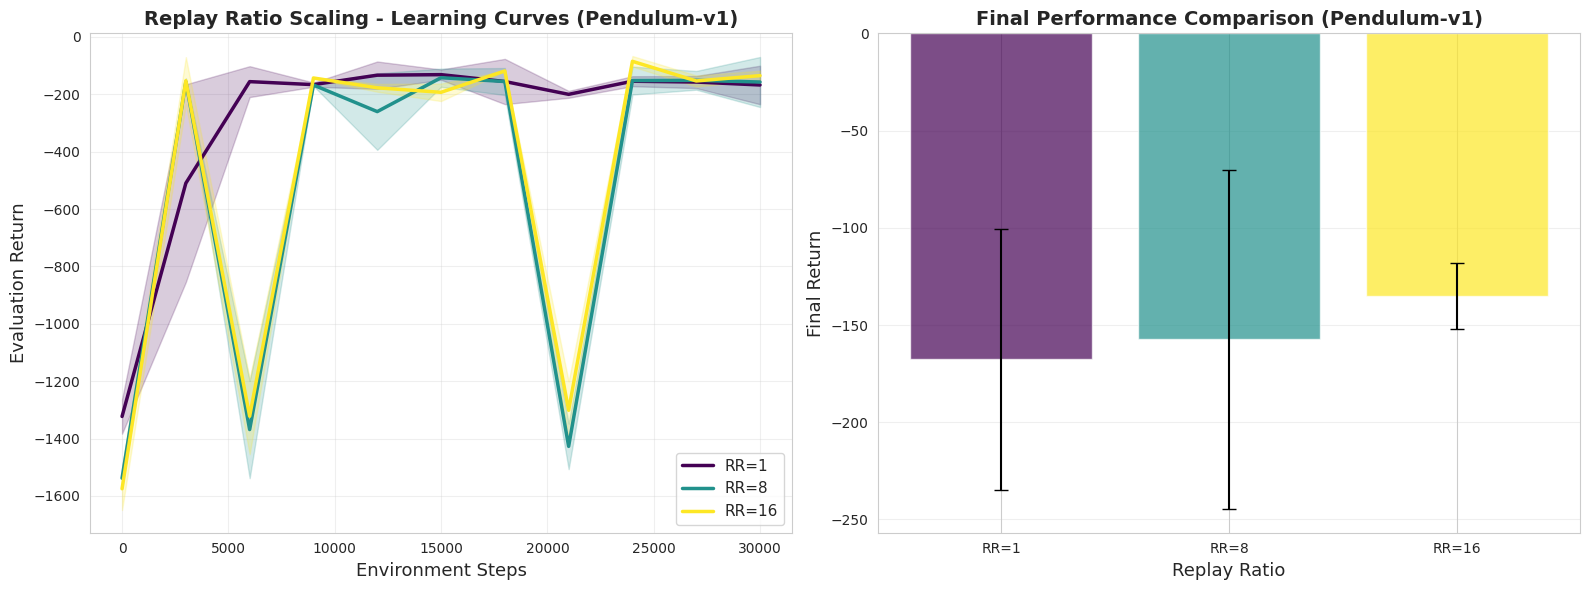

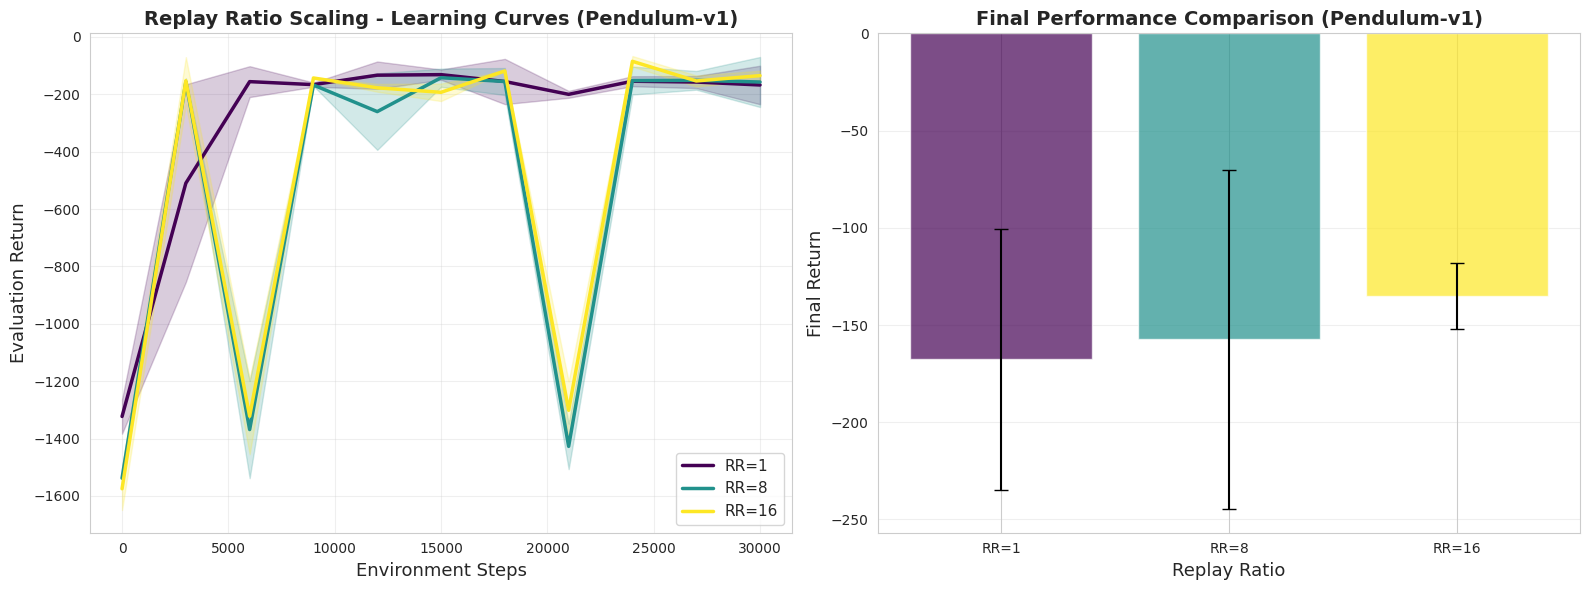

In [ ]:
def plot_replay_ratio_scaling(results_df: pd.DataFrame, title: str = ""):
    """Визуализация replay ratio scaling"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    replay_ratios = sorted(results_df['replay_ratio'].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(replay_ratios)))
    
    for rr, color in zip(replay_ratios, colors):
        data = results_df[results_df['replay_ratio'] == rr]
        grouped = data.groupby('step')['eval_return'].agg(['mean', 'std']).reset_index()
        
        ax1.plot(grouped['step'], grouped['mean'],
                label=f'RR={rr}', color=color, linewidth=2.5)
        ax1.fill_between(grouped['step'],
                        grouped['mean'] - grouped['std'],
                        grouped['mean'] + grouped['std'],
                        alpha=0.2, color=color)
    
    ax1.set_xlabel('Environment Steps', fontsize=13)
    ax1.set_ylabel('Evaluation Return', fontsize=13)
    ax1.set_title(f'Replay Ratio Scaling - Learning Curves {title}', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    final_means = []
    final_stds = []
    
    for rr in replay_ratios:
        rr_data = results_df[results_df['replay_ratio'] == rr]
        final_returns = rr_data.groupby('seed')['eval_return'].last()
        final_means.append(final_returns.mean())
        final_stds.append(final_returns.std())
    
    ax2.bar(range(len(replay_ratios)), final_means, yerr=final_stds,
           color=colors, alpha=0.7, capsize=5)
    ax2.set_xticks(range(len(replay_ratios)))
    ax2.set_xticklabels([f'RR={rr}' for rr in replay_ratios])
    ax2.set_xlabel('Replay Ratio', fontsize=13)
    ax2.set_ylabel('Final Return', fontsize=13)
    ax2.set_title(f'Final Performance Comparison {title}', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('exp1_replay_ratio_scaling.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

plot_replay_ratio_scaling(exp1_results, f"({config.ENV_NAME})")

## 5. Эксперимент 2: Эффект сбросов параметров <a name="exp2"></a>

**Цель:** Доказать, что именно resets позволяют эффективное replay ratio scaling.

**Гипотеза из статьи:** Без resets агент деградирует при высоких RR из-за loss of plasticity.

In [ ]:
def experiment_ablation_resets(
    env_name: str = config.ENV_NAME,
    replay_ratio: int = 16,
    total_steps: int = config.TOTAL_ENV_STEPS,
    num_seeds: int = config.NUM_SEEDS,
) -> pd.DataFrame:
    
    print("\n" + "="*70)
    print("🧪 ЭКСПЕРИМЕНТ 2: ABLATION - RESETS vs NO RESETS")
    print("="*70)
    print(f"Среда: {env_name}")
    print(f"Replay Ratio: {replay_ratio} (фиксированный)")
    print(f"Seeds: {num_seeds}")
    print("="*70)
    
    all_results = []
    
    configs = [
        {'use_resets': True, 'rr': replay_ratio, 'label': f'SR-SAC (RR={replay_ratio}, with resets)'},
        {'use_resets': False, 'rr': replay_ratio, 'label': f'SAC (RR={replay_ratio}, NO resets)'},
        {'use_resets': False, 'rr': 1, 'label': 'Baseline SAC (RR=1)'},
    ]
    
    for cfg in configs:
        print(f"\n📊 {cfg['label']}")
        
        for seed in range(num_seeds):
            print(f"   Seed {seed + 1}/{num_seeds}", end=" ")
            
            agent, history = train_agent(
                env_name=env_name,
                replay_ratio=cfg['rr'],
                use_resets=cfg['use_resets'],
                reset_interval=40000,
                total_steps=total_steps,
                eval_frequency=config.EVAL_FREQUENCY,
                seed=seed,
                verbose=False
            )
            
            history['method'] = cfg['label']
            history['use_resets'] = cfg['use_resets']
            history['replay_ratio'] = cfg['rr']
            history['seed'] = seed
            all_results.append(history)
            
            final_return = history['eval_return'].iloc[-1]
            print(f"→ Final: {final_return:.1f}")
    
    results_df = pd.concat(all_results, ignore_index=True)
    
    print("\n✅ Эксперимент 2 завершён!")
    
    print("\n📈 Финальные returns:")
    for cfg in configs:
        method_data = results_df[results_df['method'] == cfg['label']]
        final_returns = method_data.groupby('seed')['eval_return'].last()
        mean_ret = final_returns.mean()
        std_ret = final_returns.std()
        print(f"   {cfg['label'][:30]:30s}: {mean_ret:6.1f} ± {std_ret:5.1f}")
    
    return results_df

In [ ]:
exp2_results = experiment_ablation_resets()

exp2_results.to_csv('exp2_ablation_resets.csv', index=False)
print("\n💾 Результаты сохранены: exp2_ablation_resets.csv")


🧪 ЭКСПЕРИМЕНТ 2: ABLATION - RESETS vs NO RESETS
Среда: Pendulum-v1
Replay Ratio: 16 (фиксированный)
Seeds: 2

📊 SR-SAC (RR=16, with resets)
   Seed 1/2 
🔄 RESET #1 после 40000 updates
   ✓ Буфер сохранён: 3500 transitions

🔄 RESET #2 после 80000 updates
   ✓ Буфер сохранён: 6000 transitions

🔄 RESET #3 после 120000 updates
   ✓ Буфер сохранён: 8500 transitions

🔄 RESET #4 после 160000 updates
   ✓ Буфер сохранён: 11000 transitions

🔄 RESET #5 после 200000 updates
   ✓ Буфер сохранён: 13500 transitions

🔄 RESET #6 после 240000 updates
   ✓ Буфер сохранён: 16000 transitions

🔄 RESET #7 после 280000 updates
   ✓ Буфер сохранён: 18500 transitions

🔄 RESET #8 после 320000 updates
   ✓ Буфер сохранён: 21000 transitions

🔄 RESET #9 после 360000 updates
   ✓ Буфер сохранён: 23500 transitions

🔄 RESET #10 после 400000 updates
   ✓ Буфер сохранён: 26000 transitions

🔄 RESET #11 после 440000 updates
   ✓ Буфер сохранён: 28500 transitions
→ Final: -163.5
   Seed 2/2 
🔄 RESET #1 после 40000 update

### Визуализация Эксперимента 2

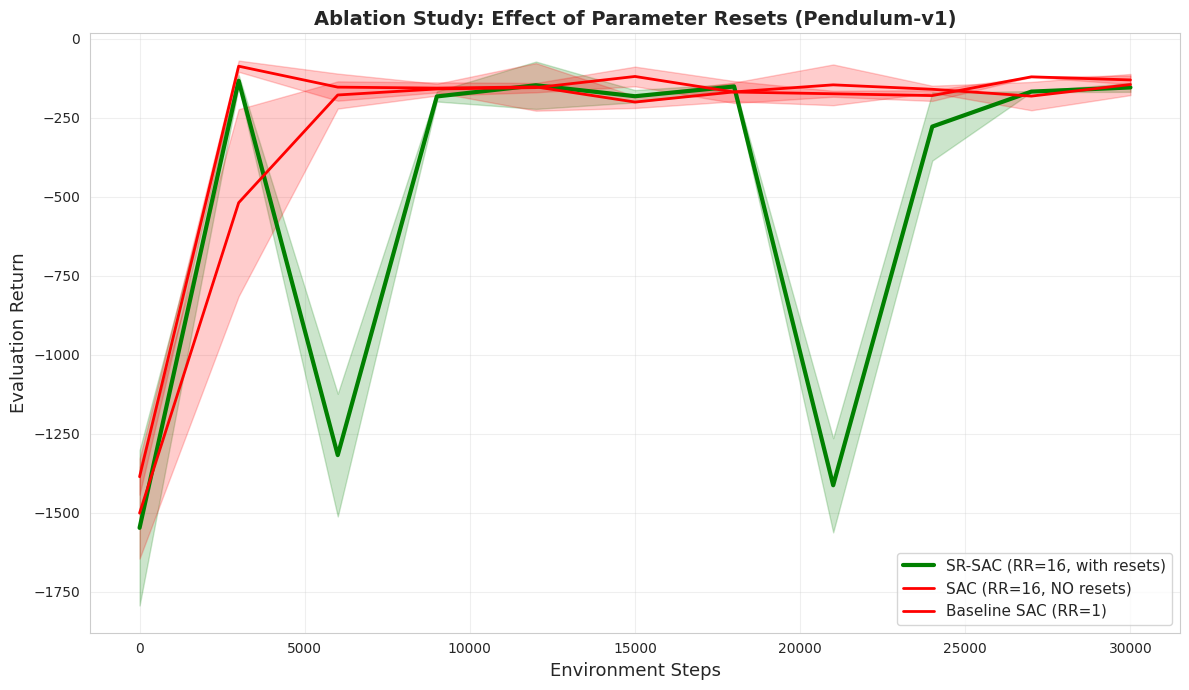

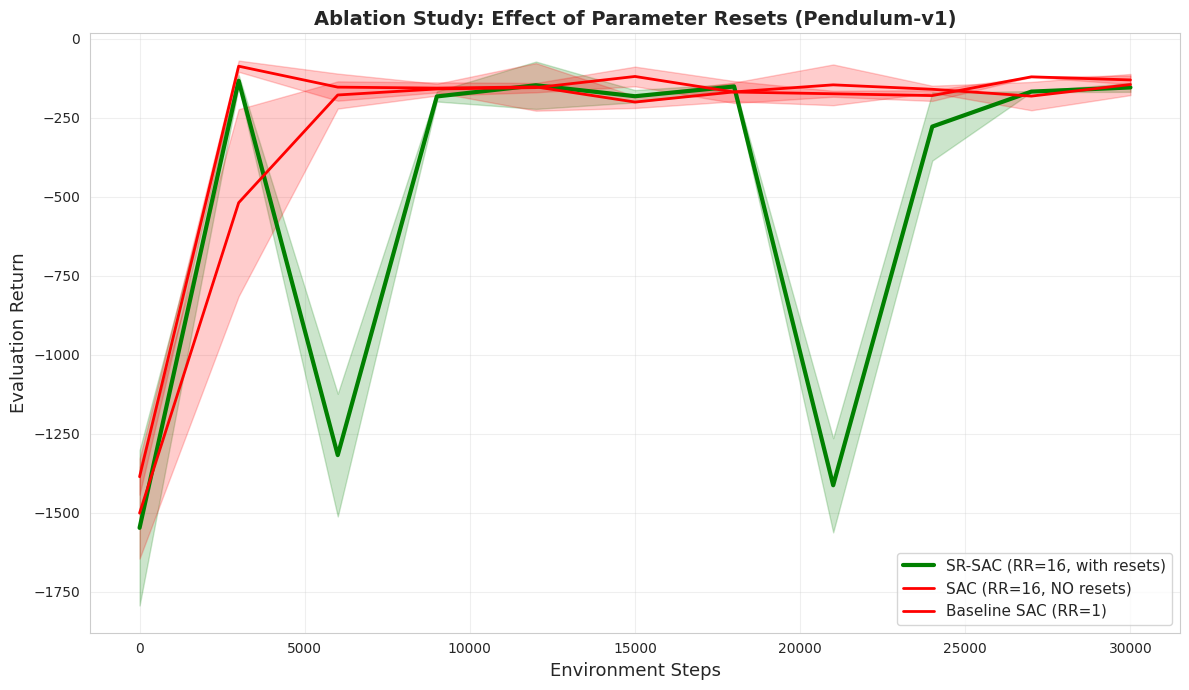

In [ ]:
def plot_ablation(results_df: pd.DataFrame, title: str = ""):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    
    methods = results_df['method'].unique()
    colors_map = {
        'SR-SAC': 'green',
        'SAC': 'red', 
        'Baseline': 'gray'
    }
    
    for method in methods:
        data = results_df[results_df['method'] == method]
        grouped = data.groupby('step')['eval_return'].agg(['mean', 'std']).reset_index()
        
        color = 'blue'
        for key, col in colors_map.items():
            if key in method:
                color = col
                break
        
        linewidth = 3 if 'SR-SAC' in method else 2
        
        ax.plot(grouped['step'], grouped['mean'],
               label=method, color=color, linewidth=linewidth)
        ax.fill_between(grouped['step'],
                       grouped['mean'] - grouped['std'],
                       grouped['mean'] + grouped['std'],
                       alpha=0.2, color=color)
    
    ax.set_xlabel('Environment Steps', fontsize=13)
    ax.set_ylabel('Evaluation Return', fontsize=13)
    ax.set_title(f'Ablation Study: Effect of Parameter Resets {title}', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('exp2_ablation_resets.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

plot_ablation(exp2_results, f"({config.ENV_NAME})")

## 6. Эксперимент 3: Влияние интервала сброса <a name="exp3"></a>

**Цель:** Понять, как частота resets влияет на производительность.

**Гипотеза из статьи:** Существует оптимальный интервал сброса; слишком частые или редкие resets могут навредить.

In [ ]:
def experiment_reset_interval(
    env_name: str = config.ENV_NAME,
    replay_ratio: int = 16,
    reset_intervals: List[int] = [10000, 20000, 40000],
    total_steps: int = config.TOTAL_ENV_STEPS,
    num_seeds: int = config.NUM_SEEDS,
) -> pd.DataFrame:
    """
    Эксперимент 3: Reset Interval Study
    """
    print("\n" + "="*70)
    print("🧪 ЭКСПЕРИМЕНТ 3: RESET INTERVAL STUDY")
    print("="*70)
    print(f"Среда: {env_name}")
    print(f"Replay Ratio: {replay_ratio}")
    print(f"Reset Intervals: {reset_intervals}")
    print(f"Seeds: {num_seeds}")
    print("="*70)
    
    all_results = []
    
    for interval in reset_intervals:
        print(f"\n📊 Reset Interval = {interval} updates ({interval//1000}k)")
        
        for seed in range(num_seeds):
            print(f"   Seed {seed + 1}/{num_seeds}", end=" ")
            
            agent, history = train_agent(
                env_name=env_name,
                replay_ratio=replay_ratio,
                use_resets=True,
                reset_interval=interval,
                total_steps=total_steps,
                eval_frequency=config.EVAL_FREQUENCY,
                seed=seed,
                verbose=False
            )
            
            history['reset_interval'] = interval
            history['seed'] = seed
            all_results.append(history)
            
            final_return = history['eval_return'].iloc[-1]
            num_resets = history['total_resets'].iloc[-1]
            print(f"→ Final: {final_return:.1f} ({num_resets} resets)")
    
    results_df = pd.concat(all_results, ignore_index=True)
    
    print("\n✅ Эксперимент 3 завершён!")
    
    print("\n📈 Финальные returns:")
    for interval in reset_intervals:
        int_data = results_df[results_df['reset_interval'] == interval]
        final_returns = int_data.groupby('seed')['eval_return'].last()
        mean_ret = final_returns.mean()
        std_ret = final_returns.std()
        print(f"   Interval {interval//1000}k: {mean_ret:6.1f} ± {std_ret:5.1f}")
    
    return results_df

In [ ]:
exp3_results = experiment_reset_interval(
    replay_ratio=8 if config.QUICK_MODE else 16,
    reset_intervals=[10000, 20000, 40000]
)

exp3_results.to_csv('exp3_reset_interval.csv', index=False)
print("\n💾 Результаты сохранены: exp3_reset_interval.csv")


🧪 ЭКСПЕРИМЕНТ 3: RESET INTERVAL STUDY
Среда: Pendulum-v1
Replay Ratio: 8
Reset Intervals: [10000, 20000, 40000]
Seeds: 2

📊 Reset Interval = 10000 updates (10k)
   Seed 1/2 
🔄 RESET #1 после 10000 updates
   ✓ Буфер сохранён: 2250 transitions

🔄 RESET #2 после 20000 updates
   ✓ Буфер сохранён: 3500 transitions

🔄 RESET #3 после 30000 updates
   ✓ Буфер сохранён: 4750 transitions

🔄 RESET #4 после 40000 updates
   ✓ Буфер сохранён: 6000 transitions

🔄 RESET #5 после 50000 updates
   ✓ Буфер сохранён: 7250 transitions

🔄 RESET #6 после 60000 updates
   ✓ Буфер сохранён: 8500 transitions

🔄 RESET #7 после 70000 updates
   ✓ Буфер сохранён: 9750 transitions

🔄 RESET #8 после 80000 updates
   ✓ Буфер сохранён: 11000 transitions

🔄 RESET #9 после 90000 updates
   ✓ Буфер сохранён: 12250 transitions

🔄 RESET #10 после 100000 updates
   ✓ Буфер сохранён: 13500 transitions

🔄 RESET #11 после 110000 updates
   ✓ Буфер сохранён: 14750 transitions

🔄 RESET #12 после 120000 updates
   ✓ Буфер сох

### Визуализация Эксперимента 3

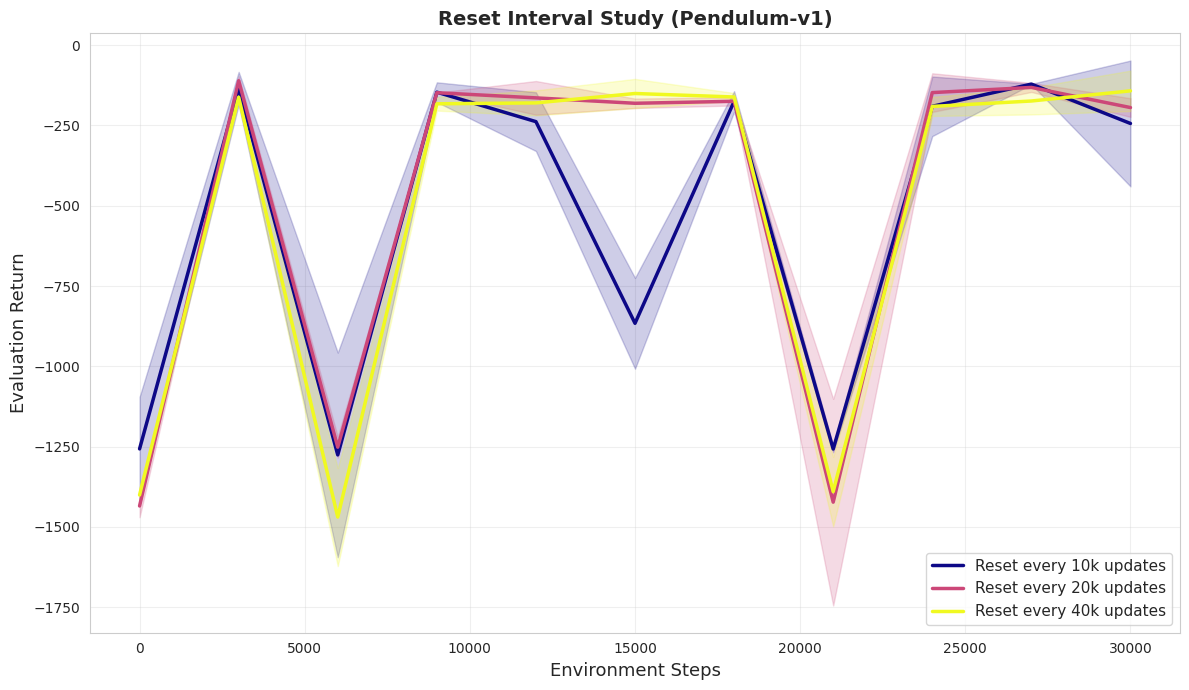

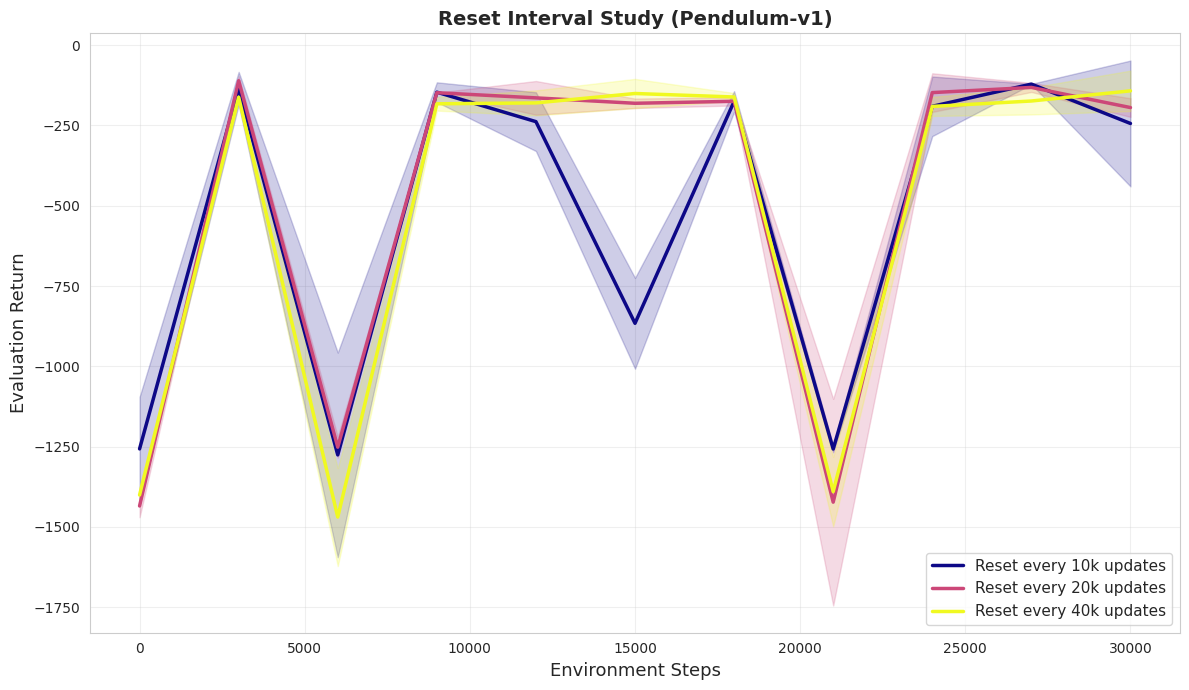

In [ ]:
def plot_reset_interval(results_df: pd.DataFrame, title: str = ""):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    
    intervals = sorted(results_df['reset_interval'].unique())
    colors = plt.cm.plasma(np.linspace(0, 1, len(intervals)))
    
    for interval, color in zip(intervals, colors):
        data = results_df[results_df['reset_interval'] == interval]
        grouped = data.groupby('step')['eval_return'].agg(['mean', 'std']).reset_index()
        
        ax.plot(grouped['step'], grouped['mean'],
               label=f'Reset every {interval//1000}k updates', 
               color=color, linewidth=2.5)
        ax.fill_between(grouped['step'],
                       grouped['mean'] - grouped['std'],
                       grouped['mean'] + grouped['std'],
                       alpha=0.2, color=color)
    
    ax.set_xlabel('Environment Steps', fontsize=13)
    ax.set_ylabel('Evaluation Return', fontsize=13)
    ax.set_title(f'Reset Interval Study {title}', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('exp3_reset_interval.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

plot_reset_interval(exp3_results, f"({config.ENV_NAME})")

In [ ]:
def create_summary_table():
    summary_data = []
    
    for rr in config.REPLAY_RATIOS:
        rr_data = exp1_results[exp1_results['replay_ratio'] == rr]
        final_returns = rr_data.groupby('seed')['eval_return'].last()
        summary_data.append({
            'Experiment': 'Exp1: RR Scaling',
            'Configuration': f'RR={rr}',
            'Mean Return': final_returns.mean(),
            'Std Return': final_returns.std(),
            'Seeds': config.NUM_SEEDS
        })
    
    for method in exp2_results['method'].unique():
        method_data = exp2_results[exp2_results['method'] == method]
        final_returns = method_data.groupby('seed')['eval_return'].last()
        summary_data.append({
            'Experiment': 'Exp2: Ablation',
            'Configuration': method,
            'Mean Return': final_returns.mean(),
            'Std Return': final_returns.std(),
            'Seeds': config.NUM_SEEDS
        })
    
    for interval in sorted(exp3_results['reset_interval'].unique()):
        int_data = exp3_results[exp3_results['reset_interval'] == interval]
        final_returns = int_data.groupby('seed')['eval_return'].last()
        summary_data.append({
            'Experiment': 'Exp3: Reset Interval',
            'Configuration': f'{interval//1000}k updates',
            'Mean Return': final_returns.mean(),
            'Std Return': final_returns.std(),
            'Seeds': config.NUM_SEEDS
        })
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

summary_table = create_summary_table()

print("\n" + "="*80)
print("📊 ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
print(summary_table.to_string(index=False))
print("="*80)

summary_table.to_csv('summary_results.csv', index=False)
print("\n💾 Сводная таблица сохранена: summary_results.csv")


📊 ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
          Experiment               Configuration  Mean Return  Std Return  Seeds
    Exp1: RR Scaling                        RR=1  -167.733464   67.127789      2
    Exp1: RR Scaling                        RR=8  -157.385437   87.203369      2
    Exp1: RR Scaling                       RR=16  -135.133393   17.111538      2
      Exp2: Ablation SR-SAC (RR=16, with resets)  -153.679364   13.926297      2
      Exp2: Ablation      SAC (RR=16, NO resets)  -144.422330   33.497368      2
      Exp2: Ablation         Baseline SAC (RR=1)  -129.841744   13.673303      2
Exp3: Reset Interval                 10k updates  -243.744838  195.899485      2
Exp3: Reset Interval                 20k updates  -194.188137   29.076749      2
Exp3: Reset Interval                 40k updates  -142.125698   63.036716      2

💾 Сводная таблица сохранена: summary_results.csv


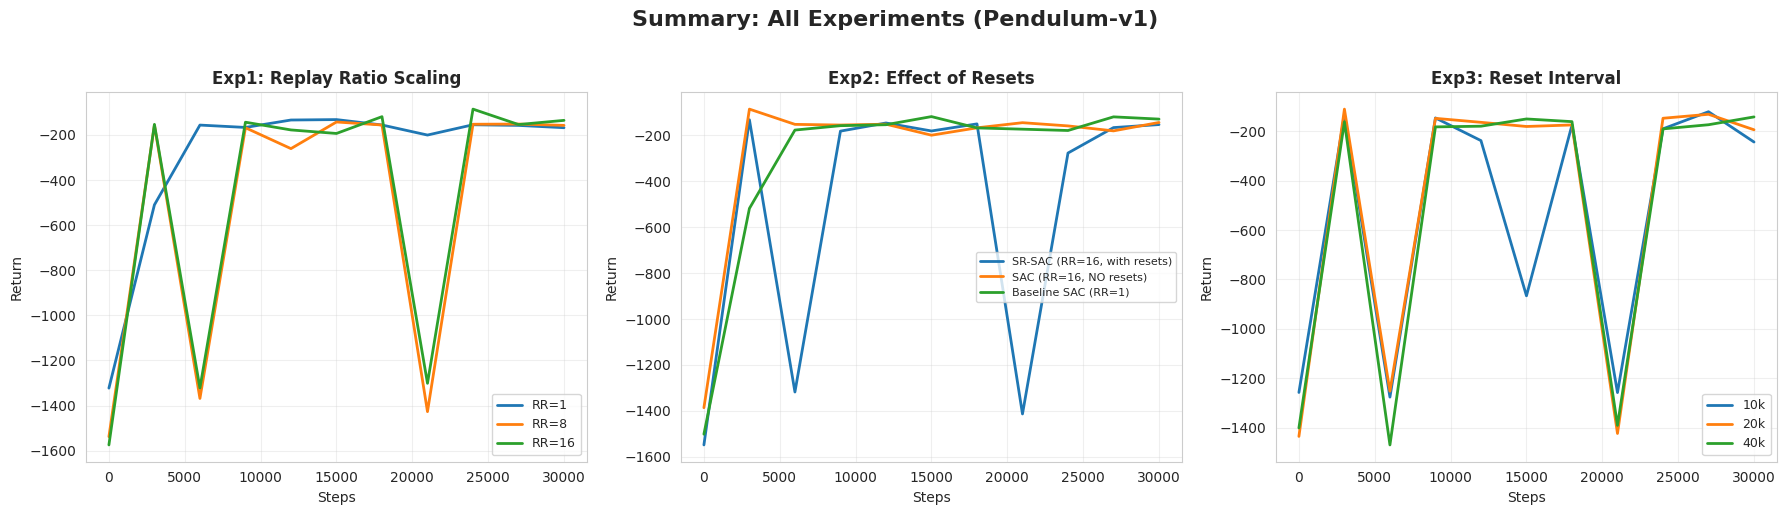


✅ Сводный график создан: all_experiments_summary.png


In [ ]:
fig = plt.figure(figsize=(18, 5))

ax1 = plt.subplot(1, 3, 1)
for rr in config.REPLAY_RATIOS:
    data = exp1_results[exp1_results['replay_ratio'] == rr]
    grouped = data.groupby('step')['eval_return'].agg(['mean']).reset_index()
    ax1.plot(grouped['step'], grouped['mean'], label=f'RR={rr}', linewidth=2)
ax1.set_xlabel('Steps')
ax1.set_ylabel('Return')
ax1.set_title('Exp1: Replay Ratio Scaling', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(1, 3, 2)
for method in exp2_results['method'].unique():
    data = exp2_results[exp2_results['method'] == method]
    grouped = data.groupby('step')['eval_return'].agg(['mean']).reset_index()
    ax2.plot(grouped['step'], grouped['mean'], label=method, linewidth=2)
ax2.set_xlabel('Steps')
ax2.set_ylabel('Return')
ax2.set_title('Exp2: Effect of Resets', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(1, 3, 3)
for interval in sorted(exp3_results['reset_interval'].unique()):
    data = exp3_results[exp3_results['reset_interval'] == interval]
    grouped = data.groupby('step')['eval_return'].agg(['mean']).reset_index()
    ax3.plot(grouped['step'], grouped['mean'], label=f'{interval//1000}k', linewidth=2)
ax3.set_xlabel('Steps')
ax3.set_ylabel('Return')
ax3.set_title('Exp3: Reset Interval', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle(f'Summary: All Experiments ({config.ENV_NAME})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_experiments_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Сводный график создан: all_experiments_summary.png")

In [ ]:
print("\n" + "="*70)
print("📈 СТАТИСТИЧЕСКИЙ АНАЛИЗ")
print("="*70)

print("\n1. Улучшение от replay ratio scaling:")
baseline_rr = min(config.REPLAY_RATIOS)
best_rr = max(config.REPLAY_RATIOS)

baseline_data = exp1_results[exp1_results['replay_ratio'] == baseline_rr]
best_data = exp1_results[exp1_results['replay_ratio'] == best_rr]

baseline_mean = baseline_data.groupby('seed')['eval_return'].last().mean()
best_mean = best_data.groupby('seed')['eval_return'].last().mean()

improvement = ((best_mean - baseline_mean) / abs(baseline_mean)) * 100
print(f"   RR={baseline_rr}: {baseline_mean:.1f}")
print(f"   RR={best_rr}: {best_mean:.1f}")
print(f"   Improvement: {improvement:+.1f}%")

print("\n2. Эффект сбросов параметров:")
with_resets = exp2_results[exp2_results['method'].str.contains('SR-SAC')]
no_resets = exp2_results[
    (exp2_results['method'].str.contains('NO resets')) & 
    (exp2_results['replay_ratio'] == 16)
]

with_resets_mean = with_resets.groupby('seed')['eval_return'].last().mean()
no_resets_mean = no_resets.groupby('seed')['eval_return'].last().mean()

reset_improvement = ((with_resets_mean - no_resets_mean) / abs(no_resets_mean)) * 100
print(f"   With resets: {with_resets_mean:.1f}")
print(f"   Without resets: {no_resets_mean:.1f}")
print(f"   Difference: {reset_improvement:+.1f}%")

print("\n3. Оптимальный reset interval:")
best_interval = None
best_interval_score = -np.inf

for interval in sorted(exp3_results['reset_interval'].unique()):
    int_data = exp3_results[exp3_results['reset_interval'] == interval]
    mean_score = int_data.groupby('seed')['eval_return'].last().mean()
    print(f"   {interval//1000}k: {mean_score:.1f}")
    
    if mean_score > best_interval_score:
        best_interval = interval
        best_interval_score = mean_score

print(f"   → Оптимальный: {best_interval//1000}k updates")

print("\n" + "="*70)


📈 СТАТИСТИЧЕСКИЙ АНАЛИЗ

1. Улучшение от replay ratio scaling:
   RR=1: -167.7
   RR=16: -135.1
   Improvement: +19.4%

2. Эффект сбросов параметров:
   With resets: -153.7
   Without resets: -144.4
   Difference: -6.4%

3. Оптимальный reset interval:
   10k: -243.7
   20k: -194.2
   40k: -142.1
   → Оптимальный: 40k updates

